# Model development

In [16]:
from sanity_functions import *

In [17]:
transactions = pd.read_csv('../data/processed/raw_transactions.csv')
transactions.head()

,event_created_at,amount,infraction,merchant_id,mc_weeks_signup,mc_atm_br_tx_out_count_lifetime,mc_credit_transfer_out_br_sum_last_30d,mc_billpay_br_sum_last_15d,mc_billpay_br_count_last_1y,mc_credit_transfer_out_br_sum_last_1y,...,mc_tx_cp_dbt_sum_sq_fail_last_14d,mc_merchants_ip_count_dist_shared_last_15d,mcc_sum_succ_1y,mcc_sum_sq_succ_30d,mcc_count_succ_1y,mcc_sum_sq_succ_1y,mcc_sum_succ_30d,is_legal_entity,is_mei,is_person
0,2024-02-02 21:43:57.697,275.0,0,DAQQ7TS,322.285714,0.0,411.133179,0.000000,0.0,5048.175078,...,0.0000,0.0,7.523910e+08,1.404402e+11,4232421,1.548410e+12,6.384952e+07,0,0,1
1,2024-02-02 20:49:30.476,2805.5,0,CR4K9VY,66.285714,0.0,35289.128889,170.986536,13.0,334646.251337,...,423018.1025,0.0,7.412321e+08,9.651831e+10,8401389,2.947039e+12,2.877422e+07,0,0,1
2,2024-02-02 15:32:12.033,150.0,0,DSSEHKE,284.142857,0.0,1585.621610,0.000000,0.0,10383.890144,...,0.0000,0.0,2.189377e+09,3.328640e+11,18806623,3.802283e+12,1.733248e+08,0,1,0
3,2024-02-02 13:21:08.696,177.0,0,2C2EP9Y,38.857143,0.0,2659.310168,0.000000,46.0,23495.076815,...,5147.0000,0.0,9.638338e+07,4.847552e+09,2114366,6.598435e+10,8.536190e+06,0,0,1
4,2024-02-02 18:32:29.093,259.0,0,C3NYGCP,39.142857,0.0,1663.235351,0.000000,14.0,13035.453581,...,0.0000,1.0,2.997443e+09,5.486961e+11,31893920,5.762067e+12,2.198331e+08,0,0,1


In [18]:
transactions.shape
# (991.965, 91)

(991965, 91)

## Null

In [20]:
import pandas as pd
from scipy import stats


def analyze_nulls_relationship_with_fraud(df):
    """
    Analyze if null values in each column are related to fraud
    by comparing fraud rates and using chi-square test
    """
    results = []

    # Get total fraud rate for reference
    total_fraud_rate = df['infraction'].mean()

    for column in df.columns:
        if column != 'infraction' and df[column].isnull().any():
            # Calculate fraud rates
            fraud_rate_null = df[df[column].isnull()]['infraction'].mean()
            fraud_rate_not_null = df[df[column].notnull()]['infraction'].mean()

            # Create contingency table for chi-square test
            contingency = pd.crosstab(df[column].isnull(), df['infraction'])

            # Perform chi-square test
            chi2, p_value = stats.chi2_contingency(contingency)[:2]

            # Calculate percentage of nulls
            null_percentage = (df[column].isnull().sum() / len(df)) * 100

            # Calculate relative difference in fraud rates
            if fraud_rate_not_null > 0:
                relative_difference = (fraud_rate_null - fraud_rate_not_null) / fraud_rate_not_null
            else:
                relative_difference = np.inf if fraud_rate_null > 0 else 0

            results.append({
                'Column': column,
                'Null_Percentage': null_percentage,
                'Fraud_Rate_Null': fraud_rate_null,
                'Fraud_Rate_Not_Null': fraud_rate_not_null,
                'Relative_Difference': relative_difference,
                'Chi_Square': chi2,
                'P_Value': p_value,
                'Is_Significant': p_value < 0.05,
                'Conclusion': 'Related to fraud' if p_value < 0.05 else 'Random'
            })

    # Convert to DataFrame and sort by significance
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('P_Value')

    # Format percentages and float values
    results_df['Null_Percentage'] = results_df['Null_Percentage'].round(2)
    results_df['Fraud_Rate_Null'] = results_df['Fraud_Rate_Null'].round(4)
    results_df['Fraud_Rate_Not_Null'] = results_df['Fraud_Rate_Not_Null'].round(4)
    results_df['Relative_Difference'] = results_df['Relative_Difference'].round(2)
    results_df['P_Value'] = results_df['P_Value'].apply(lambda x: f'{x:.2e}')

    return results_df


# Load the data
df = pd.read_csv('../data/processed/raw_transactions.csv')

# Run the analysis
results = analyze_nulls_relationship_with_fraud(df)

# Print results
print("\nNull Values Analysis Results:")
print("\nColumns with significant relationship to fraud (p < 0.05):")
significant = results[results['Is_Significant']]
print(significant[
          ['Column', 'Null_Percentage', 'Fraud_Rate_Null', 'Fraud_Rate_Not_Null', 'Relative_Difference', 'P_Value']])

print("\nColumns with random null distribution (p >= 0.05):")
not_significant = results[~results['Is_Significant']]
print(not_significant[
          ['Column', 'Null_Percentage', 'Fraud_Rate_Null', 'Fraud_Rate_Not_Null', 'Relative_Difference', 'P_Value']])

# Save detailed results
results.to_csv('null_analysis_results.csv', index=False)


Null Values Analysis Results:

Columns with significant relationship to fraud (p < 0.05):
                                               Column  Null_Percentage  \
1                     mc_atm_br_tx_out_count_lifetime             0.38   
3                         mc_billpay_br_count_last_1y             0.39   
5                             mc_pur_br_count_last_1y             0.39   
4               mc_credit_transfer_out_br_sum_last_1y             1.25   
6                        mc_billpay_br_count_last_15d             1.59   
7                      mc_atm_br_tx_out_count_last_1y             0.39   
10           mc_credit_transfer_out_br_count_lifetime             0.38   
9              mc_credit_transfer_in_br_sum_last_180d             1.11   
14             mc_credit_transfer_in_br_sum_last_120d             1.27   
13                           mc_pur_br_count_last_15d             1.59   
11  mc_credit_transfer_out_br_count_sanction_last_30d             0.89   
12           mc_credi

In [21]:
caract_df(transactions)

Nº linhas: 991965
Nº colunas: 91
Nº linhas duplicadas: 0

Nº de vazios*:
	mc_weeks_signup: 11252 - 1.13%
	mc_atm_br_tx_out_count_lifetime: 3799 - 0.38%
	mc_credit_transfer_out_br_sum_last_30d: 27259 - 2.75%
	mc_billpay_br_count_last_1y: 3827 - 0.39%
	mc_credit_transfer_out_br_sum_last_1y: 12432 - 1.25%
	mc_pur_br_count_last_1y: 3827 - 0.39%
	mc_billpay_br_count_last_15d: 15779 - 1.59%
	mc_atm_br_tx_out_count_last_1y: 3827 - 0.39%
	mc_sanction_count_last_2d: 203567 - 20.52%
	mc_credit_transfer_in_br_sum_last_180d: 11013 - 1.11%
	mc_credit_transfer_out_br_count_lifetime: 3799 - 0.38%
	mc_credit_transfer_out_br_count_sanction_last_30d: 8817 - 0.89%
	mc_credit_transfer_out_br_count_last_15d: 15779 - 1.59%
	mc_pur_br_count_last_15d: 15779 - 1.59%
	mc_credit_transfer_in_br_sum_last_120d: 12627 - 1.27%
	mc_pur_br_count_lifetime: 3799 - 0.38%
	mc_credit_transfer_in_br_count_last_30d: 8817 - 0.89%
	mc_credit_transfer_in_br_sum_last_90d: 14011 - 1.41%
	mc_credit_transfer_out_br_count_last_1y: 38

In [22]:
def treat_missing_values(df):
    """
    Comprehensive missing value treatment preserving the signal from null values
    """
    # Create a copy to avoid modifying the original dataframe
    df_treated = df.copy()

    # Store columns to process (excluding target and non-numeric columns)
    columns_to_process = df.select_dtypes(include=['float64', 'int64']).columns
    columns_to_process = [col for col in columns_to_process if
                          not col in ['infraction', 'merchant_id', 'event_created_at']]

    # # Create null indicator features
    # for column in columns_to_process:
    #     if df[column].isnull().any():
    #         # Create missing indicator
    #         df_treated[f'{column}_is_null'] = df[column].isnull().astype(int)

    # Different imputation strategies

    # knn_imputer = KNNImputer(n_neighbors=5)

    # 2. Forward fill for time-dependent features
    df_treated['event_created_at'] = pd.to_datetime(df_treated['event_created_at'])
    df_treated = df_treated.sort_values('event_created_at')

    for column in columns_to_process:
        if df[column].isnull().any():
            # Calculate the fraud rate difference for null vs non-null
            fraud_rate_null = df[df[column].isnull()]['infraction'].mean()
            fraud_rate_non_null = df[df[column].notnull()]['infraction'].mean()
            ratio = fraud_rate_null / fraud_rate_non_null if fraud_rate_non_null > 0 else np.inf

            # Choose imputation strategy based on fraud rate ratio
            if ratio > 10:  # If nulls are much more likely to be fraud
                # Use a special value (e.g., -999) to preserve the signal
                df_treated[column] = df_treated[column].fillna(-999999)
            else:
                df_treated[column] = df_treated[column].fillna(df_treated[column].median())

            # else:
            #    df_treated[column] = pd.DataFrame(
            #         knn_imputer.fit_transform(df_treated[[column]]),
            #         columns=[column],
            #         index=df_treated.index
            #     )

    # # Fill any remaining nulls with median
    # for column in columns_to_process:
    #     if df_treated[column].isnull().any():
    #         df_treated[column] = df_treated[column].fillna(df_treated[column].median())

    return df_treated


# Example usage:
df = pd.read_csv('../data/processed/raw_transactions.csv')

# Get original null counts
null_counts_before = df.isnull().sum()
print("\nNull counts before treatment:")
print(null_counts_before[null_counts_before > 0])

# Apply treatment
df_treated = treat_missing_values(df)

# Get null counts after treatment
null_counts_after = df_treated.isnull().sum()
print("\nNull counts after treatment:")
print(null_counts_after[null_counts_after > 0])

# Print new features created
new_features = [col for col in df_treated.columns if col not in df.columns]
print("\nNew indicator features created:")
print(new_features)


Null counts before treatment:
mc_weeks_signup                                       11252
mc_atm_br_tx_out_count_lifetime                        3799
mc_credit_transfer_out_br_sum_last_30d                27259
mc_billpay_br_count_last_1y                            3827
mc_credit_transfer_out_br_sum_last_1y                 12432
mc_pur_br_count_last_1y                                3827
mc_billpay_br_count_last_15d                          15779
mc_atm_br_tx_out_count_last_1y                         3827
mc_sanction_count_last_2d                            203567
mc_credit_transfer_in_br_sum_last_180d                11013
mc_credit_transfer_out_br_count_lifetime               3799
mc_credit_transfer_out_br_count_sanction_last_30d      8817
mc_credit_transfer_out_br_count_last_15d              15779
mc_pur_br_count_last_15d                              15779
mc_credit_transfer_in_br_sum_last_120d                12627
mc_pur_br_count_lifetime                               3799
mc_credit

In [23]:
df_treated

,event_created_at,amount,infraction,merchant_id,mc_weeks_signup,mc_atm_br_tx_out_count_lifetime,mc_credit_transfer_out_br_sum_last_30d,mc_billpay_br_sum_last_15d,mc_billpay_br_count_last_1y,mc_credit_transfer_out_br_sum_last_1y,...,mc_tx_cp_dbt_sum_sq_fail_last_14d,mc_merchants_ip_count_dist_shared_last_15d,mcc_sum_succ_1y,mcc_sum_sq_succ_30d,mcc_count_succ_1y,mcc_sum_sq_succ_1y,mcc_sum_succ_30d,is_legal_entity,is_mei,is_person
473558,2023-07-01 00:01:02.493914,107.5,0,D62L9GQ,69.714286,0.0,1440.115473,65.510513,19.0,12698.963010,...,0.00,1.0,2.302048e+09,6.907739e+11,20826995,6.583108e+12,2.301642e+08,0,0,1
806288,2023-07-01 00:01:13.949476,138.5,0,ECF6ENP,71.142857,0.0,1733.728697,718.527985,77.0,9497.237914,...,250.75,0.0,2.144144e+09,3.740267e+11,19358946,3.356191e+12,1.778138e+08,0,0,1
636880,2023-07-01 00:01:32.933130,150.0,0,UK3ZG3M,258.285714,2.0,175.442214,0.000000,0.0,625.039834,...,0.00,0.0,2.144144e+09,3.740267e+11,19358946,3.356191e+12,1.778138e+08,0,0,1
511561,2023-07-01 00:01:41.744530,135.0,0,CZYH6X7,48.857143,0.0,2615.888201,0.000000,4.0,10640.710971,...,0.00,0.0,2.144144e+09,3.740267e+11,19358946,3.356191e+12,1.778138e+08,0,0,1
687219,2023-07-01 00:01:56.158400,418.0,0,G9PY39Y,190.142857,0.0,1406.257142,0.000000,0.0,9565.032061,...,1028.00,0.0,3.039484e+09,1.524340e+11,101862055,2.233361e+12,2.345546e+08,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204941,2024-05-01 23:58:40.446000,600.0,0,PQ2QDEX,65.285714,0.0,6376.565975,204.061248,18.0,89037.053401,...,1768900.00,0.0,2.020037e+08,6.221600e+10,1213249,6.899038e+11,1.966357e+07,0,0,1
26153,2024-05-01 23:58:45.363000,200.0,0,4V2CR26,253.142857,0.0,5533.079508,0.000000,61.0,41480.860678,...,0.00,0.0,2.217093e+09,3.983409e+11,18281557,4.095064e+12,1.924288e+08,0,0,1
130562,2024-05-01 23:59:49.887000,145.0,0,CCNGDNG,4.142857,0.0,1217.194475,367.828938,4.0,1217.194475,...,0.00,0.0,2.776819e+09,2.310073e+11,93005969,2.290934e+12,2.214253e+08,0,0,1
211337,2024-05-01 23:59:52.112000,150.0,0,CSHCSKM,185.285714,0.0,591.842026,22.174899,12.0,6399.846418,...,0.00,0.0,1.674791e+09,1.370278e+11,51236362,1.531982e+12,1.394113e+08,0,0,1


## Class imbalance

In [8]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

def evaluate_model(model_name, y_true, y_pred, y_proba):
    """Calculate evaluation metrics with model name prefix"""
    metrics = {
        f'{model_name}_Precision': precision_score(y_true, y_pred, zero_division=0),
        f'{model_name}_Recall': recall_score(y_true, y_pred, zero_division=0),
        f'{model_name}_F1-Score': f1_score(y_true, y_pred, zero_division=0),
        f'{model_name}_Avg Precision': average_precision_score(y_true, y_proba),
    }

    # Calculate Precision@100
    y_proba_series = pd.Series(y_proba, index=y_true.index)
    top_100 = y_proba_series.nlargest(100)
    metrics[f'{model_name}_Precision@100'] = y_true.loc[top_100.index].mean()

    return metrics


def train_and_evaluate(X_train, X_test, y_train, y_test, sampler_name, sampler=None):
    """Train and evaluate both models with given sampler"""
    print(f"\nProcessing {sampler_name}...")
    results = {}

    try:
        # Apply sampling only on training data
        if sampler is not None:
            X_res, y_res = sampler.fit_resample(X_train, y_train)
            print(f"Resampled shape: {X_res.shape}, Fraud ratio: {y_res.mean():.4f}")
        else:
            X_res, y_res = X_train, y_train

        class_ratio = len(y_res[y_res == 0]) / len(y_res[y_res == 1])

        # ========== LightGBM ==========
        try:
            lgb_model = lgb.LGBMClassifier(
                n_estimators=1000,
                learning_rate=0.01,
                num_leaves=32,
                scale_pos_weight=class_ratio,
                random_state=42,
                verbose=-1
            )
            lgb_model.fit(X_res, y_res)
            lgb_pred = lgb_model.predict(X_test)
            lgb_proba = lgb_model.predict_proba(X_test)[:, 1]
            results.update(evaluate_model('LGBM', y_test, lgb_pred, lgb_proba))
        except Exception as e:
            print(f"LightGBM Error: {str(e)}")

        # ========== XGBoost ==========
        try:
            xgb_model = xgb.XGBClassifier(
                n_estimators=1000,
                learning_rate=0.01,
                max_depth=5,
                scale_pos_weight=class_ratio,
                eval_metric='aucpr',
                random_state=42
            )
            xgb_model.fit(X_res, y_res)
            xgb_pred = xgb_model.predict(X_test)
            xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
            results.update(evaluate_model('XGB', y_test, xgb_pred, xgb_proba))
        except Exception as e:
            print(f"XGBoost Error: {str(e)}")

        return results

    except Exception as e:
        print(f"General Error: {str(e)}")
        return {k: np.nan for k in [
            'LGBM_Precision', 'LGBM_Recall', 'LGBM_F1-Score', 'LGBM_Avg Precision', 'LGBM_Precision@100',
            'XGB_Precision', 'XGB_Recall', 'XGB_F1-Score', 'XGB_Avg Precision', 'XGB_Precision@100'
        ]}


def main():
    """Main execution flow"""
    # Load and prepare data
    # df = pd.read_parquet('sumup_cas.parquet').sort_values('event_created_at')
    df = df_treated.sort_values('event_created_at').copy()

    # Feature selection
    X = df.drop(['infraction', 'event_created_at', 'merchant_id'], axis=1)
    y = df['infraction']

    # Time-based split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2,
        # shuffle=False
    )

    # Define samplers with 20% fraud target
    samplers = {
        'No Sampling': None,
        'Random Under': RandomUnderSampler(sampling_strategy=0.25, random_state=42),
        'SMOTE': SMOTE(sampling_strategy=0.25, random_state=42),
        # 'ADASYN': ADASYN(sampling_strategy=0.25, random_state=42),
        # 'SMOTE-Tomek': SMOTETomek(sampling_strategy=0.25, random_state=42),
        # 'SMOTE-ENN': SMOTEENN(sampling_strategy=0.25, random_state=42)
    }

    # Evaluate all samplers
    results = {}
    for name, sampler in samplers.items():
        results[name] = train_and_evaluate(X_train, X_test, y_train, y_test, name, sampler)

    # Save and display results
    results_df = pd.DataFrame(results).T
    results_df.to_csv('sampling_results.csv', float_format='%.4f')

    print("\nFinal Results:")
    print(results_df)

    return results_df


if __name__ == "__main__":
    main()


Processing No Sampling...


C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py:158: UserWarning: [18:28:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Processing Random Under...
Resampled shape: (19990, 88), Fraud ratio: 0.2000


C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py:158: UserWarning: [18:29:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Processing SMOTE...
Resampled shape: (986967, 88), Fraud ratio: 0.2000


C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py:158: UserWarning: [18:31:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Final Results:
              LGBM_Precision  LGBM_Recall  LGBM_F1-Score  LGBM_Avg Precision  \
No Sampling         0.163205     0.924827       0.277448            0.477344   
Random Under        0.140550     0.929773       0.244188            0.457074   
SMOTE               0.212440     0.878338       0.342131            0.483515   

              LGBM_Precision@100  XGB_Precision  XGB_Recall  XGB_F1-Score  \
No Sampling                 0.79       0.137287    0.922849      0.239016   
Random Under                0.77       0.126603    0.927794      0.222803   
SMOTE                       0.75       0.172785    0.889219      0.289347   

              XGB_Avg Precision  XGB_Precision@100  
No Sampling            0.444206               0.75  
Random Under           0.434317               0.76  
SMOTE                  0.450041               0.76  


## Feature engineering

In [24]:
# 1. Create weekend flag:
#    Weekday numbers: Monday=0, Tuesday=1, ... Sunday=6.
#    Set flag = 1 for Saturday (5) or Sunday (6), else 0.
df_treated['is_weekend'] = df_treated['event_created_at'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

# 2. Create night flag:
#    We define "day" as from 6:00 (6 AM) to 18:00 (6 PM). Transactions outside that range are considered "night".
df_treated['is_night'] = df_treated['event_created_at'].dt.hour.apply(lambda x: 1 if (x < 6 or x >= 18) else 0)

# 3. Extract additional temporal features: month, day, and hour.
df_treated['month'] = df_treated['event_created_at'].dt.month
df_treated['day'] = df_treated['event_created_at'].dt.day
df_treated['hour'] = df_treated['event_created_at'].dt.hour

df_treated.to_csv('../data/processed/df_treated.csv', index=False)

df_treated

,event_created_at,amount,infraction,merchant_id,mc_weeks_signup,mc_atm_br_tx_out_count_lifetime,mc_credit_transfer_out_br_sum_last_30d,mc_billpay_br_sum_last_15d,mc_billpay_br_count_last_1y,mc_credit_transfer_out_br_sum_last_1y,...,mcc_sum_sq_succ_1y,mcc_sum_succ_30d,is_legal_entity,is_mei,is_person,is_weekend,is_night,month,day,hour
473558,2023-07-01 00:01:02.493914,107.5,0,D62L9GQ,69.714286,0.0,1440.115473,65.510513,19.0,12698.963010,...,6.583108e+12,2.301642e+08,0,0,1,1,1,7,1,0
806288,2023-07-01 00:01:13.949476,138.5,0,ECF6ENP,71.142857,0.0,1733.728697,718.527985,77.0,9497.237914,...,3.356191e+12,1.778138e+08,0,0,1,1,1,7,1,0
636880,2023-07-01 00:01:32.933130,150.0,0,UK3ZG3M,258.285714,2.0,175.442214,0.000000,0.0,625.039834,...,3.356191e+12,1.778138e+08,0,0,1,1,1,7,1,0
511561,2023-07-01 00:01:41.744530,135.0,0,CZYH6X7,48.857143,0.0,2615.888201,0.000000,4.0,10640.710971,...,3.356191e+12,1.778138e+08,0,0,1,1,1,7,1,0
687219,2023-07-01 00:01:56.158400,418.0,0,G9PY39Y,190.142857,0.0,1406.257142,0.000000,0.0,9565.032061,...,2.233361e+12,2.345546e+08,0,0,1,1,1,7,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204941,2024-05-01 23:58:40.446000,600.0,0,PQ2QDEX,65.285714,0.0,6376.565975,204.061248,18.0,89037.053401,...,6.899038e+11,1.966357e+07,0,0,1,0,1,5,1,23
26153,2024-05-01 23:58:45.363000,200.0,0,4V2CR26,253.142857,0.0,5533.079508,0.000000,61.0,41480.860678,...,4.095064e+12,1.924288e+08,0,0,1,0,1,5,1,23
130562,2024-05-01 23:59:49.887000,145.0,0,CCNGDNG,4.142857,0.0,1217.194475,367.828938,4.0,1217.194475,...,2.290934e+12,2.214253e+08,0,0,1,0,1,5,1,23
211337,2024-05-01 23:59:52.112000,150.0,0,CSHCSKM,185.285714,0.0,591.842026,22.174899,12.0,6399.846418,...,1.531982e+12,1.394113e+08,0,0,1,0,1,5,1,23


## Classification


=== Training DecisionTree ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits

=== Training RandomForest ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits

=== Training XGBoost ===
Fitting 5 folds for each of 60 candidates, totalling 300 fits


C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py:158: UserWarning: [14:28:09] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== Training AdaBoost ===
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Final Model Comparison:
                Recall Precision@100 Avg Precision   ROC_AUC  \
XGBoost       0.903626           0.7      0.451091  0.973077   
RandomForest  0.900763          0.91      0.553442  0.976406   
DecisionTree  0.873092          0.03      0.130034   0.92608   
AdaBoost      0.848282          0.64       0.35088  0.964991   

                                                    Best Params  
XGBoost       {'model__learning_rate': 0.1, 'model__max_dept...  
RandomForest  {'model__max_depth': 50, 'model__n_estimators'...  
DecisionTree  {'model__max_depth': 10, 'model__min_samples_s...  
AdaBoost      {'model__learning_rate': 0.25, 'model__n_estim...  


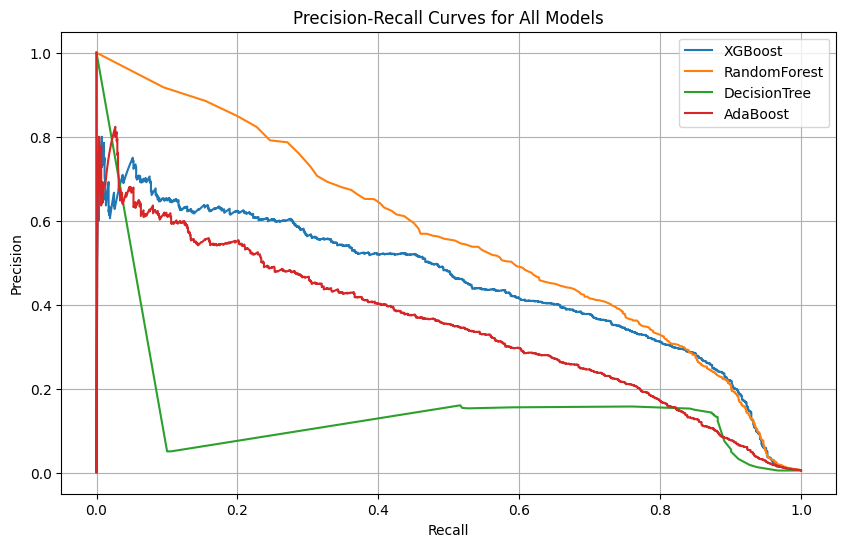


Best Model: XGBoost with Recall 0.9036


In [14]:
from sklearn.model_selection import StratifiedKFold
from joblib import parallel_backend
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_recall_curve

# 1. Load and prepare data
# df = pd.read_parquet('sumup_cas.parquet').sort_values('event_created_at')
# df = df_treated.copy()
df = pd.read_csv('../data/processed/df_treated.csv')
X = df.drop(['infraction', 'event_created_at', 'merchant_id'], axis=1)
y = df['infraction']

# Time-based split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

# 2. Define model collection with parameter grids
models = {
    'DecisionTree': (
        DecisionTreeClassifier(),
        {'model__max_depth': [5, 10, 20, 50],
         'model__min_samples_split': [2, 5]}
    ),
    'RandomForest': (
        RandomForestClassifier(),
        {'model__n_estimators': [20, 100, 200, 500],
         'model__max_depth': [5, 10, 20, 50]}
    ),
    # 'SVM': (
    #     SVC(probability=True),
    #     {'model__C': [0.1, 1, 10],
    #      'model__kernel': ['linear', 'rbf', 'poly']}
    # ),
    'XGBoost': (
        XGBClassifier(eval_metric='aucpr'),
        {'model__learning_rate': [0.01, 0.1, 0.25],
         'model__max_depth': [5, 10, 20, 50],
         'model__n_estimators': [20, 50, 100, 200, 500]}
    ),
    'AdaBoost': (
        AdaBoostClassifier(),
        {'model__n_estimators': [20, 50, 100, 200, 500],
         'model__learning_rate': [0.01, 0.1, 0.25]}
    ),
    # 'LightGBM': (
    #     lgb.LGBMClassifier(),
    #     {'model__num_leaves': [16, 32],
    #      'model__learning_rate': [0.01, 0.1, 0.25]}
    # ),
    # 'MLP': (
    #     MLPClassifier(early_stopping=True),
    #     {'model__hidden_layer_sizes': [(50,), (100,), (150,)],
    #      'model__alpha': [0.0001, 0.001, 0.002]}
    # )
}

# 3. Train and validate models
results = {}
best_estimators = {}

for model_name, (estimator, param_grid) in models.items():
    try:
        print(f"\n=== Training {model_name} ===")

        # Create pipeline with RUS and model
        pipeline = Pipeline([
            ('sampler', RandomUnderSampler(sampling_strategy=0.25, random_state=42)),
            ('model', estimator)
        ])

        # Grid search with recall optimization
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring='recall',
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            n_jobs=-1,
            verbose=1
        )

        # Use multiprocessing backend for better memory management
        with parallel_backend('multiprocessing'):
            grid.fit(X_train, y_train)

        # Store best model
        best_estimators[model_name] = grid.best_estimator_

        # Validate on test set
        y_pred = grid.best_estimator_.predict(X_test)
        y_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]

        # Calculate metrics
        precision, recall, _ = precision_recall_curve(y_test, y_proba)

        results[model_name] = {
            'Best Params': grid.best_params_,
            'Recall': recall_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC_AUC': roc_auc_score(y_test, y_proba),
            'Avg Precision': average_precision_score(y_test, y_proba),
            'Precision@100': y_test[pd.Series(y_proba, index=y_test.index).nlargest(100).index].mean(),
            'Confusion_Matrix': confusion_matrix(y_test, y_pred).tolist(),
            'PR_Curve': {
                'Precision': precision.tolist(),
                'Recall': recall.tolist()
            }
        }

    except Exception as e:
        print(f"Error with {model_name}: {str(e)}")
        results[model_name] = 'Failed'

# 4. Save and display results
results_df = pd.DataFrame(results).T.sort_values('Recall', ascending=False)
results_df.to_csv('model_selection_results.csv', float_format='%.4f')

print("\nFinal Model Comparison:")
print(results_df[['Recall', 'Precision@100', 'Avg Precision', 'ROC_AUC', 'Best Params']])

# Plot PR curves for all models
plt.figure(figsize=(10, 6))
for model_name in results_df.index:
    if isinstance(results[model_name], dict):  # Check if model training succeeded
        pr_curve = results[model_name]['PR_Curve']
        plt.plot(pr_curve['Recall'], pr_curve['Precision'], label=f'{model_name}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for All Models')
plt.legend()
plt.grid(True)
plt.show()

# 5. Select best model based on validation recall
best_model_name = results_df.index[0]
best_model = best_estimators[best_model_name]
print(f"\nBest Model: {best_model_name} with Recall {results_df.iloc[0].Recall:.4f}")

High recall is beneficial as the false positives will be discarded anyway by the investigators, within the limit of their bandwidth.

In [17]:
best_model

Pipeline(steps=[('sampler',
                 RandomUnderSampler(random_state=42, sampling_strategy=0.25)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='aucpr',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=None,
                               num_parallel_tree=None, random_state=None, ...))])

In [21]:
import joblib
import json
import yaml
from datetime import datetime
import os
import pandas as pd
import numpy as np

def save_model_artifacts(best_model, results_df, X_train, feature_names=None, output_dir='../model/supervised'):
    """
    Save all model artifacts including the model itself, configurations, and metadata.

    Args:
        best_model: The trained model (Pipeline containing sampler and XGBoost)
        results_df: DataFrame containing model comparison results
        X_train: Training data used (for feature names)
        feature_names: List of feature names (optional)
        output_dir: Directory to save artifacts
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    # 1. Save the model
    model_path = os.path.join(output_dir, f'xgboost_model_{timestamp}.pkl')
    joblib.dump(best_model, model_path)

    # 2. Extract XGBoost model from pipeline
    xgb_model = best_model.named_steps['model']

    # 3. Save model configuration
    model_config = {
        'model_type': 'XGBoost',
        'timestamp': timestamp,
        'feature_names': feature_names if feature_names else X_train.columns.tolist(),
        'model_parameters': xgb_model.get_params(),
        'feature_importance': {
            name: float(score)
            for name, score in zip(
                X_train.columns,
                xgb_model.feature_importances_
            )
        },
        'performance_metrics': {
            metric: float(value) if isinstance(value, (np.float64, np.float32)) else value
            for metric, value in results_df.iloc[0].items()
            if metric != 'Best Params' and metric != 'Confusion_Matrix' and metric != 'PR_Curve'
        },
        'preprocessing': {
            'sampling_strategy': best_model.named_steps['sampler'].get_params()['sampling_strategy'],
            'random_state': best_model.named_steps['sampler'].get_params()['random_state']
        }
    }

    # Save as YAML for human readability
    config_path = os.path.join(output_dir, f'model_config_{timestamp}.yaml')
    with open(config_path, 'w') as f:
        yaml.dump(model_config, f, default_flow_style=False)

    # 4. Save feature importance plot
    plt.figure(figsize=(10, 6))
    feature_importance = pd.Series(
        xgb_model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=True)

    feature_importance.plot(kind='barh')
    plt.title('XGBoost Feature Importance')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'feature_importance_{timestamp}.png'))
    plt.close()

    # 5. Generate model card
    model_card = f"""
# XGBoost Model Card

## Model Information
- Model Type: XGBoost Classifier
- Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
- Model Version: {timestamp}

## Performance Metrics
- Recall: {results_df.iloc[0]['Recall']:.4f}
- Precision: {results_df.iloc[0]['Precision']:.4f}
- F1-Score: {results_df.iloc[0]['F1-Score']:.4f}
- ROC AUC: {results_df.iloc[0]['ROC_AUC']:.4f}
- Average Precision: {results_df.iloc[0]['Avg Precision']:.4f}
- Precision@100: {results_df.iloc[0]['Precision@100']:.4f}

## Model Configuration
- Sampling Strategy: {best_model.named_steps['sampler'].get_params()['sampling_strategy']}
- Random State: {best_model.named_steps['sampler'].get_params()['random_state']}

## Usage
```python
import joblib

# Load the model
model = joblib.load('{model_path}')

# Make predictions
predictions = model.predict(X)
probabilities = model.predict_proba(X)
```

## Files
- Model: {os.path.basename(model_path)}
- Config: {os.path.basename(config_path)}
- Feature Importance Plot: feature_importance_{timestamp}.png

## Notes
- Model includes preprocessing pipeline with RandomUnderSampler
- Feature importance plot available in artifacts directory
- Full configuration details in YAML file
    """

    # Save model card
    with open(os.path.join(output_dir, f'model_card_{timestamp}.md'), 'w') as f:
        f.write(model_card)

    print(f"\nModel artifacts saved in directory: {output_dir}")
    print(f"Model file: {os.path.basename(model_path)}")
    print(f"Config file: {os.path.basename(config_path)}")
    print(f"Model card: model_card_{timestamp}.md")

    return {
        'model_path': model_path,
        'config_path': config_path,
        'timestamp': timestamp
    }

# Function to load the model and make predictions
def load_model_and_predict(model_path, X):
    """
    Load the saved model and make predictions.

    Args:
        model_path: Path to the saved model file
        X: Features to predict on

    Returns:
        Tuple of (predictions, probabilities)
    """
    model = joblib.load(model_path)
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)[:, 1]
    return predictions, probabilities

# Save all model artifacts
artifacts = save_model_artifacts(
    best_model=best_model,
    results_df=results_df,
    X_train=X_train
)

# Example of loading and using the model
# new_predictions, new_probabilities = load_model_and_predict(artifacts['model_path'], X_test)


Model artifacts saved in directory: ../model/supervised
Model file: xgboost_model_20250212_144931.pkl
Config file: model_config_20250212_144931.yaml
Model card: model_card_20250212_144931.md


C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


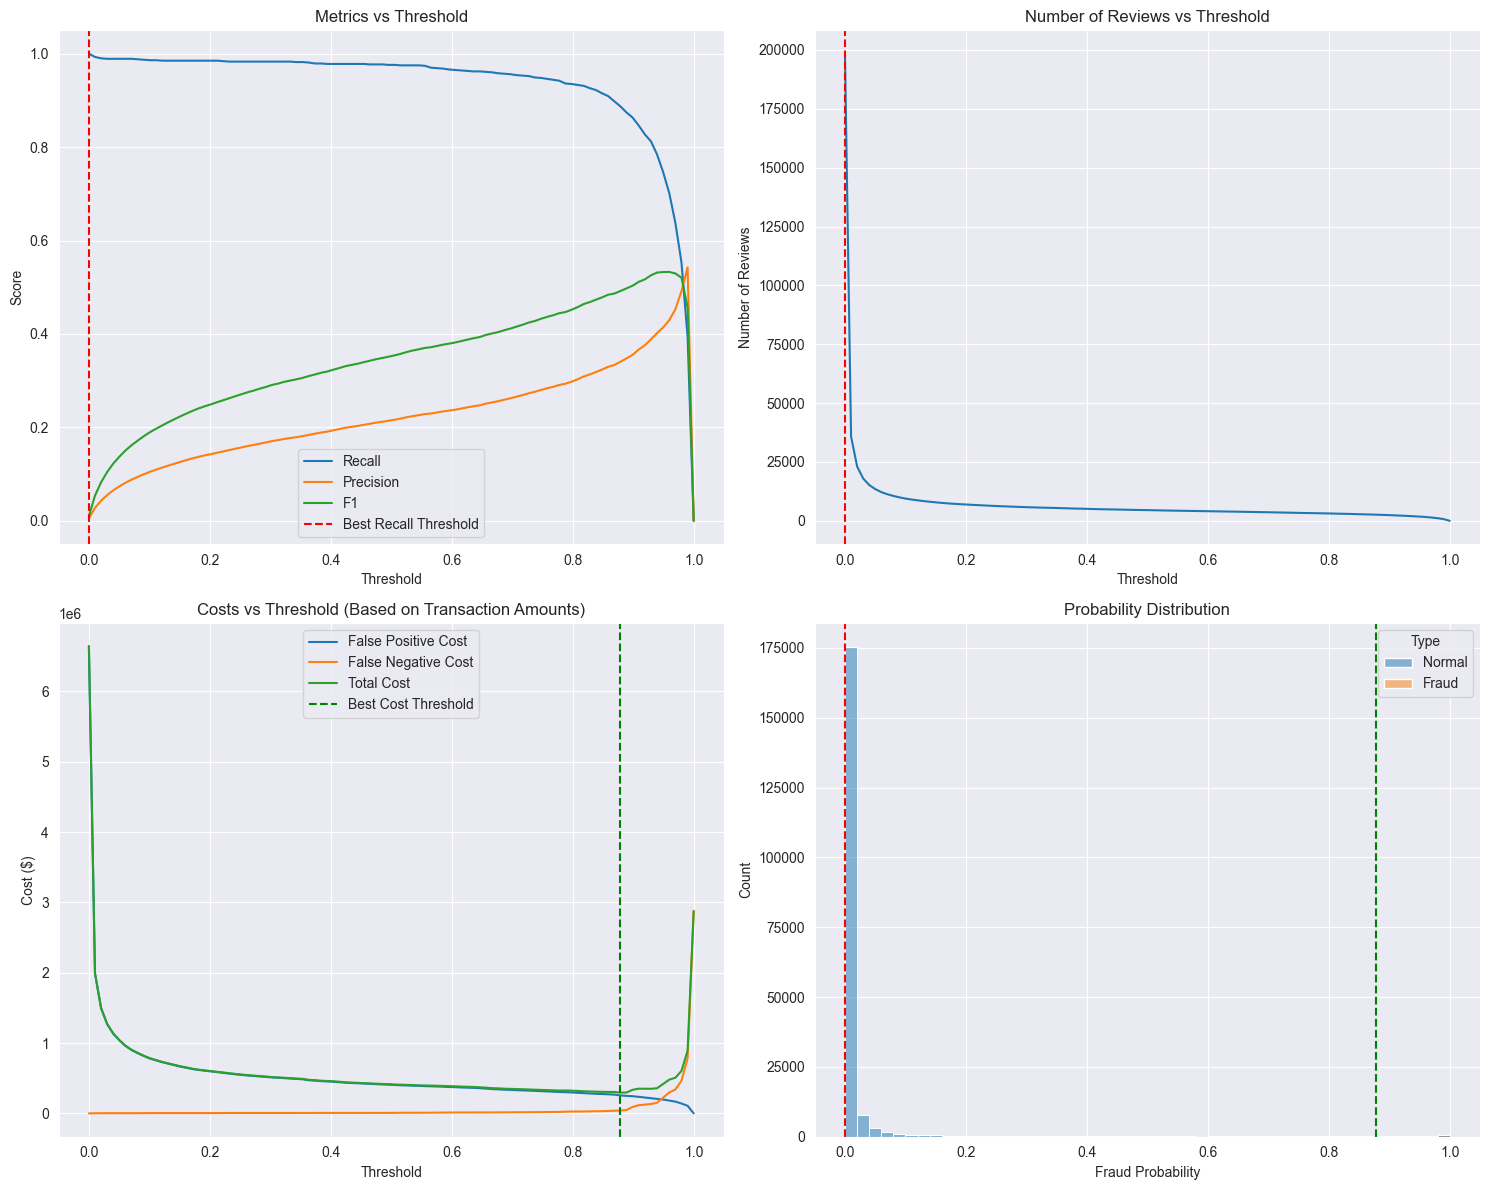


Best Threshold for Minimum Cost:
Threshold: 0.8788
Recall: 0.8872
Precision: 0.3404
F1-Score: 0.4920
Number of Reviews: 2612.0
Caught Frauds: 889.0
Missed Frauds: 113.0
False Positive Cost: $254,781.62
False Negative Cost: $39,943.01
Total Cost: $294,724.63


In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
import joblib
from sklearn.metrics import recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_xgboost_thresholds(df, n_thresholds=100):
    """
    Train XGBoost and analyze different probability thresholds
    """
    # Prepare features - exclude categorical columns and convert to numeric
    df = df.copy()

    X = df.drop(['infraction', 'event_created_at', 'merchant_id'], axis=1)
    y = df['infraction']

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Load pre-trained model
    model = joblib.load('../model/supervised/xgboost_model_20250212_144931.pkl')
    probas = model.predict_proba(X_test)[:, 1]
    # Analyze different thresholds
    thresholds = np.linspace(0, 1, n_thresholds)
    results = []

    for threshold in thresholds:
        # Get predictions for this threshold
        predictions = (probas > threshold).astype(int)

        # Calculate metrics
        recall = recall_score(y_test, predictions)
        precision = precision_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)
        amount = X_test['amount']
        # Calculate costs using transaction amounts
        # False Positives: unnecessarily reviewed transactions
        fp_mask = (predictions == 1) & (y_test == 0)
        fp_cost = amount[fp_mask].sum()/10

        # False Negatives: missed frauds
        fn_mask = (predictions == 0) & (y_test == 1)
        fn_cost = amount[fn_mask].sum()

        # Total cost
        total_cost = fp_cost + fn_cost

        # Count transactions
        n_reviews = sum(predictions)
        n_caught_frauds = sum((predictions == 1) & (y_test == 1))
        n_missed_frauds = sum((predictions == 0) & (y_test == 1))

        results.append({
            'threshold': threshold,
            'recall': recall,
            'precision': precision,
            'f1_score': f1,
            'n_reviews': n_reviews,
            'n_caught_frauds': n_caught_frauds,
            'n_missed_frauds': n_missed_frauds,
            'fp_cost': fp_cost,
            'fn_cost': fn_cost,
            'total_cost': total_cost
        })

    results_df = pd.DataFrame(results)

    # Find optimal thresholds
    best_recall_idx = results_df['recall'].idxmax()
    best_threshold = results_df.loc[best_recall_idx, 'threshold']

    best_cost_idx = results_df['total_cost'].idxmin()
    best_cost_threshold = results_df.loc[best_cost_idx, 'threshold']

    # Plot results
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # Plot 1: Metrics vs Threshold
    ax1.plot(results_df['threshold'], results_df['recall'], label='Recall')
    ax1.plot(results_df['threshold'], results_df['precision'], label='Precision')
    ax1.plot(results_df['threshold'], results_df['f1_score'], label='F1')
    ax1.axvline(best_threshold, color='r', linestyle='--', label='Best Recall Threshold')
    ax1.set_title('Metrics vs Threshold')
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Score')
    ax1.legend()

    # Plot 2: Number of Reviews vs Threshold
    ax2.plot(results_df['threshold'], results_df['n_reviews'])
    ax2.axvline(best_threshold, color='r', linestyle='--', label='Best Recall Threshold')
    ax2.set_title('Number of Reviews vs Threshold')
    ax2.set_xlabel('Threshold')
    ax2.set_ylabel('Number of Reviews')

    # Plot 3: Costs vs Threshold
    ax3.plot(results_df['threshold'], results_df['fp_cost'], label='False Positive Cost')
    ax3.plot(results_df['threshold'], results_df['fn_cost'], label='False Negative Cost')
    ax3.plot(results_df['threshold'], results_df['total_cost'], label='Total Cost')
    ax3.axvline(best_cost_threshold, color='g', linestyle='--', label='Best Cost Threshold')
    ax3.set_title('Costs vs Threshold (Based on Transaction Amounts)')
    ax3.set_xlabel('Threshold')
    ax3.set_ylabel('Cost ($)')
    ax3.legend()

    # Plot 4: Probability Distribution
    sns.histplot(data=pd.DataFrame({
        'Fraud Probability': probas,
        'Type': ['Fraud' if y == 1 else 'Normal' for y in y_test]
    }), x='Fraud Probability', hue='Type', bins=50, ax=ax4)
    ax4.axvline(best_threshold, color='r', linestyle='--', label='Best Recall Threshold')
    ax4.axvline(best_cost_threshold, color='g', linestyle='--', label='Best Cost Threshold')
    ax4.set_title('Probability Distribution')

    plt.tight_layout()
    plt.show()

    # Print summary for best cost threshold
    print("\nBest Threshold for Minimum Cost:")
    best_cost_results = results_df.iloc[best_cost_idx]
    print(f"Threshold: {best_cost_results['threshold']:.4f}")
    print(f"Recall: {best_cost_results['recall']:.4f}")
    print(f"Precision: {best_cost_results['precision']:.4f}")
    print(f"F1-Score: {best_cost_results['f1_score']:.4f}")
    print(f"Number of Reviews: {best_cost_results['n_reviews']}")
    print(f"Caught Frauds: {best_cost_results['n_caught_frauds']}")
    print(f"Missed Frauds: {best_cost_results['n_missed_frauds']}")
    print(f"False Positive Cost: ${best_cost_results['fp_cost']:,.2f}")
    print(f"False Negative Cost: ${best_cost_results['fn_cost']:,.2f}")
    print(f"Total Cost: ${best_cost_results['total_cost']:,.2f}")

    return model, results_df, probas

# Run the analysis
xgb_model, results_df, probas = analyze_xgboost_thresholds(df_treated)


Test set spans 306 days


C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


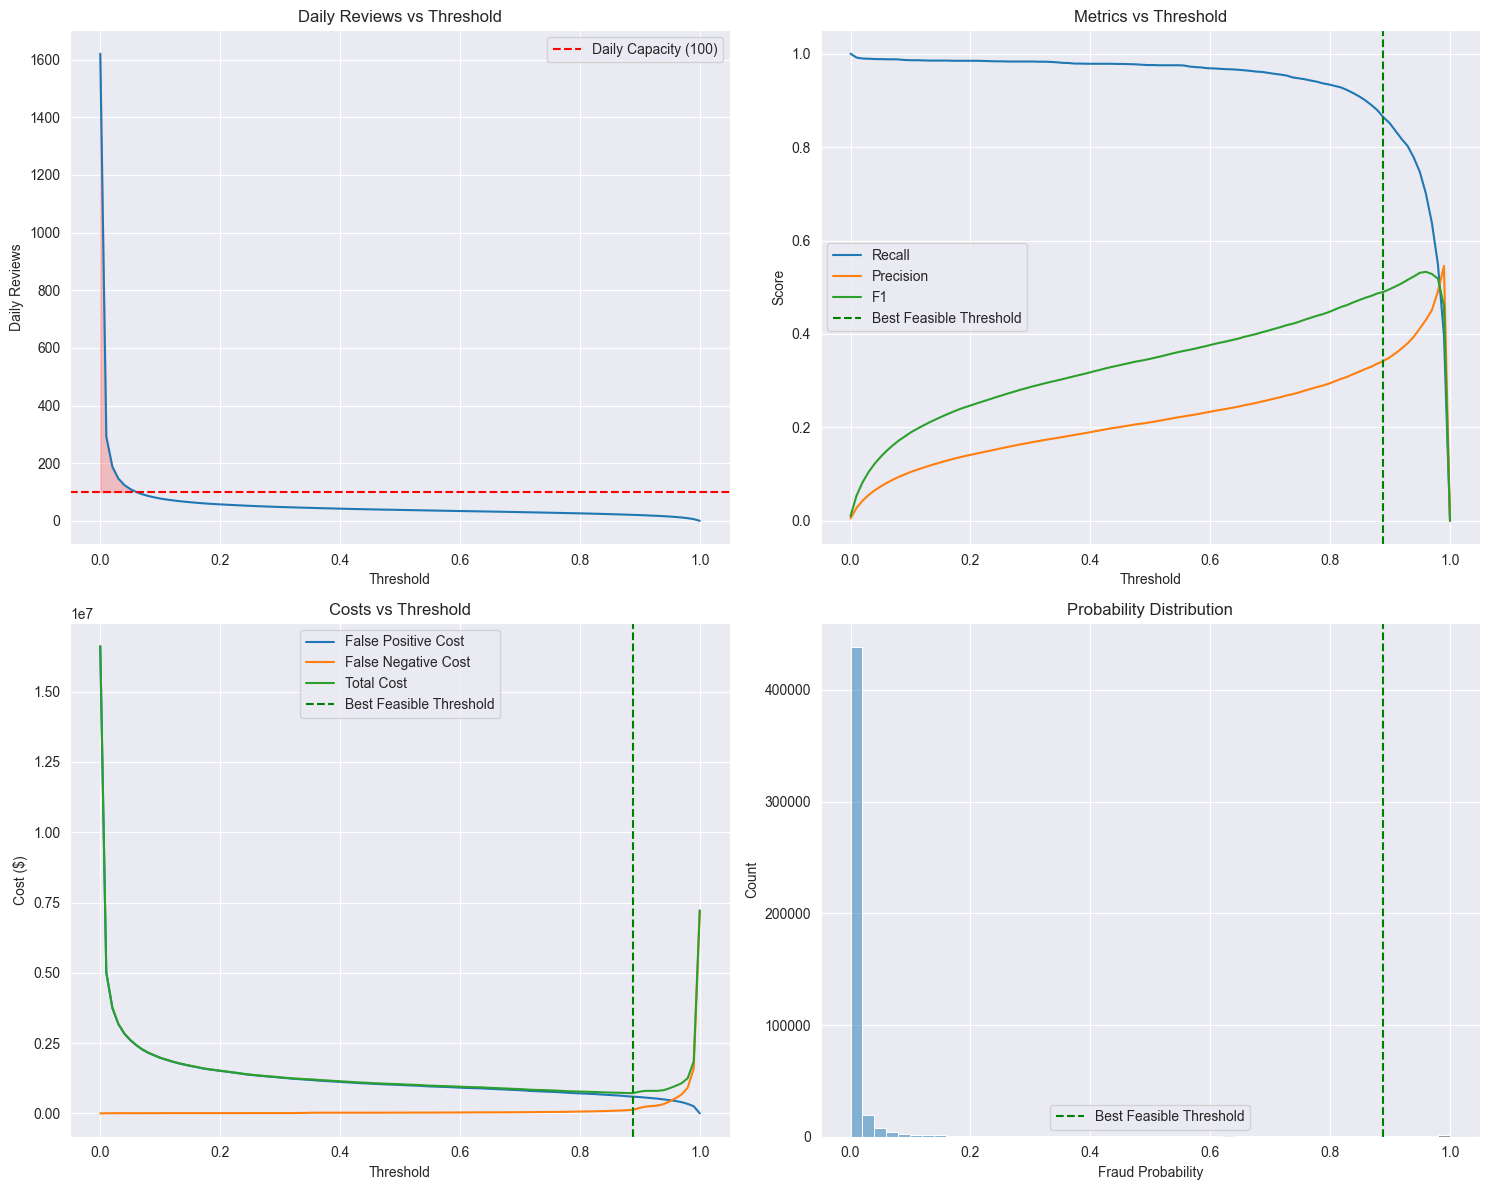


Best Feasible Threshold Analysis:
Threshold: 0.8889
Daily Reviews: 20.7 (Within Capacity)
Recall: 0.8639
Precision: 0.3420
F1-Score: 0.4900
Total Reviews: 6327
Caught Frauds: 2164
Missed Frauds: 341
False Positive Cost: $592,904.85
False Negative Cost: $128,905.67
Total Cost: $721,810.52

Threshold Analysis at Different Levels:

Threshold 0.3:
Daily Reviews: 51.8 (Within Capacity)
Recall: 0.9836
Precision: 0.1555
Total Cost: $1,374,878.45

Threshold 0.5:
Daily Reviews: 39.6 (Within Capacity)
Recall: 0.9780
Precision: 0.2020
Total Cost: $1,075,154.74

Threshold 0.7:
Daily Reviews: 31.9 (Within Capacity)
Recall: 0.9645
Precision: 0.2474
Total Cost: $903,358.05

Threshold 0.9:
Daily Reviews: 22.7 (Within Capacity)
Recall: 0.9002
Precision: 0.3249
Total Cost: $736,141.99


In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
import joblib
from sklearn.metrics import recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_xgboost_thresholds(df, max_daily_reviews=100, n_thresholds=100, fp_weight=0.1):
    """
    Train XGBoost and analyze different probability thresholds with daily review constraint

    Parameters:
    - df: DataFrame with the data
    - max_daily_reviews: Maximum number of reviews that can be handled per day
    - n_thresholds: Number of threshold points to analyze
    - fp_weight: float between 0 and 1 for the cost of false positive transacrions
    """
    # Prepare features
    df = df.copy()
    X = df.drop(['infraction', 'event_created_at', 'merchant_id'], axis=1)
    y = df['infraction']

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.5,
        # random_state=42,
        stratify=y
    )

    # Get test set dates to calculate number of days
    test_df = df.iloc[y_test.index]
    n_days = test_df['event_created_at'].dt.strftime('%Y%m%d').nunique()
    print(f"\nTest set spans {n_days} days")

    # Load pre-trained model
    model = joblib.load('../model/supervised/xgboost_model_20250212_144931.pkl')
    probas = model.predict_proba(X_test)[:, 1]

    # Analyze different thresholds
    thresholds = np.linspace(0, 1, n_thresholds)
    results = []

    for threshold in thresholds:
        # Get predictions for this threshold
        predictions = (probas > threshold).astype(int)

        # Calculate metrics
        recall = recall_score(y_test, predictions)
        precision = precision_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)
        amount = X_test['amount']

        # Calculate costs using transaction amounts
        fp_mask = (predictions == 1) & (y_test == 0)
        fp_cost = amount[fp_mask].sum() * fp_weight

        fn_mask = (predictions == 0) & (y_test == 1)
        fn_cost = amount[fn_mask].sum()

        total_cost = fp_cost + fn_cost

        # Count transactions
        n_reviews = sum(predictions)
        daily_reviews = n_reviews / n_days
        exceeds_capacity = daily_reviews > max_daily_reviews

        n_caught_frauds = sum((predictions == 1) & (y_test == 1))
        n_missed_frauds = sum((predictions == 0) & (y_test == 1))

        results.append({
            'threshold': threshold,
            'recall': recall,
            'precision': precision,
            'f1_score': f1,
            'n_reviews': n_reviews,
            'daily_reviews': daily_reviews,
            'exceeds_capacity': exceeds_capacity,
            'n_caught_frauds': n_caught_frauds,
            'n_missed_frauds': n_missed_frauds,
            'fp_cost': fp_cost,
            'fn_cost': fn_cost,
            'total_cost': total_cost
        })

    results_df = pd.DataFrame(results)

    # Find optimal thresholds considering capacity constraint
    feasible_results = results_df[~results_df['exceeds_capacity']]

    if len(feasible_results) > 0:
        best_cost_idx = feasible_results['total_cost'].idxmin()
        best_cost_threshold = results_df.loc[best_cost_idx, 'threshold']
    else:
        print("\nWarning: No threshold meets the daily review capacity constraint!")
        best_cost_idx = results_df['total_cost'].idxmin()
        best_cost_threshold = results_df.loc[best_cost_idx, 'threshold']

    # Plot results
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # Plot 1: Daily Reviews vs Threshold with Capacity
    ax1.plot(results_df['threshold'], results_df['daily_reviews'])
    ax1.axhline(y=max_daily_reviews, color='r', linestyle='--',
                label=f'Daily Capacity ({max_daily_reviews})')
    ax1.fill_between(results_df['threshold'],
                     results_df['daily_reviews'],
                     max_daily_reviews,
                     where=(results_df['daily_reviews'] > max_daily_reviews),
                     color='red', alpha=0.2)
    ax1.set_title('Daily Reviews vs Threshold')
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Daily Reviews')
    ax1.legend()

    # Plot 2: Metrics vs Threshold
    ax2.plot(results_df['threshold'], results_df['recall'], label='Recall')
    ax2.plot(results_df['threshold'], results_df['precision'], label='Precision')
    ax2.plot(results_df['threshold'], results_df['f1_score'], label='F1')
    ax2.axvline(best_cost_threshold, color='g', linestyle='--',
                label='Best Feasible Threshold')
    ax2.set_title('Metrics vs Threshold')
    ax2.set_xlabel('Threshold')
    ax2.set_ylabel('Score')
    ax2.legend()

    # Plot 3: Costs vs Threshold
    ax3.plot(results_df['threshold'], results_df['fp_cost'],
             label='False Positive Cost')
    ax3.plot(results_df['threshold'], results_df['fn_cost'],
             label='False Negative Cost')
    ax3.plot(results_df['threshold'], results_df['total_cost'],
             label='Total Cost')
    ax3.axvline(best_cost_threshold, color='g', linestyle='--',
                label='Best Feasible Threshold')
    ax3.set_title('Costs vs Threshold')
    ax3.set_xlabel('Threshold')
    ax3.set_ylabel('Cost ($)')
    ax3.legend()

    # Plot 4: Probability Distribution
    sns.histplot(data=pd.DataFrame({
        'Fraud Probability': probas,
        'Type': ['Fraud' if y == 1 else 'Normal' for y in y_test]
    }), x='Fraud Probability', hue='Type', bins=50, ax=ax4)
    ax4.axvline(best_cost_threshold, color='g', linestyle='--',
                label='Best Feasible Threshold')
    ax4.set_title('Probability Distribution')
    ax4.legend()

    plt.tight_layout()
    plt.show()

    # Print summary for best feasible threshold
    print("\nBest Feasible Threshold Analysis:")
    best_results = results_df.iloc[best_cost_idx]
    print(f"Threshold: {best_results['threshold']:.4f}")
    print(f"Daily Reviews: {best_results['daily_reviews']:.1f} "
          f"({'EXCEEDS' if best_results['exceeds_capacity'] else 'Within'} Capacity)")
    print(f"Recall: {best_results['recall']:.4f}")
    print(f"Precision: {best_results['precision']:.4f}")
    print(f"F1-Score: {best_results['f1_score']:.4f}")
    print(f"Total Reviews: {best_results['n_reviews']}")
    print(f"Caught Frauds: {best_results['n_caught_frauds']}")
    print(f"Missed Frauds: {best_results['n_missed_frauds']}")
    print(f"False Positive Cost: ${best_results['fp_cost']:,.2f}")
    print(f"False Negative Cost: ${best_results['fn_cost']:,.2f}")
    print(f"Total Cost: ${best_results['total_cost']:,.2f}")

    # Print threshold recommendations
    print("\nThreshold Analysis at Different Levels:")
    for threshold in [0.3, 0.5, 0.7, 0.9]:
        thresh_data = results_df[results_df['threshold'].round(1) == threshold].iloc[0]
        capacity_status = "EXCEEDS CAPACITY" if thresh_data['exceeds_capacity'] else "Within Capacity"
        print(f"\nThreshold {threshold}:")
        print(f"Daily Reviews: {thresh_data['daily_reviews']:.1f} ({capacity_status})")
        print(f"Recall: {thresh_data['recall']:.4f}")
        print(f"Precision: {thresh_data['precision']:.4f}")
        print(f"Total Cost: ${thresh_data['total_cost']:,.2f}")

    return model, results_df, probas

# Run the analysis
xgb_model, results_df, probas = analyze_xgboost_thresholds(
    df_treated,
    max_daily_reviews=100  # Adjust based on your team's capacity
)

## Regression


=== Training XGBoost ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Class distribution in training data after resampling:
infraction
0    0.8
1    0.2
Name: proportion, dtype: float64

Final Model Comparison:
         R2_Score      RMSE       MAE  High_Risk_Precision
XGBoost -3.016941  0.140729  0.059611             0.297011


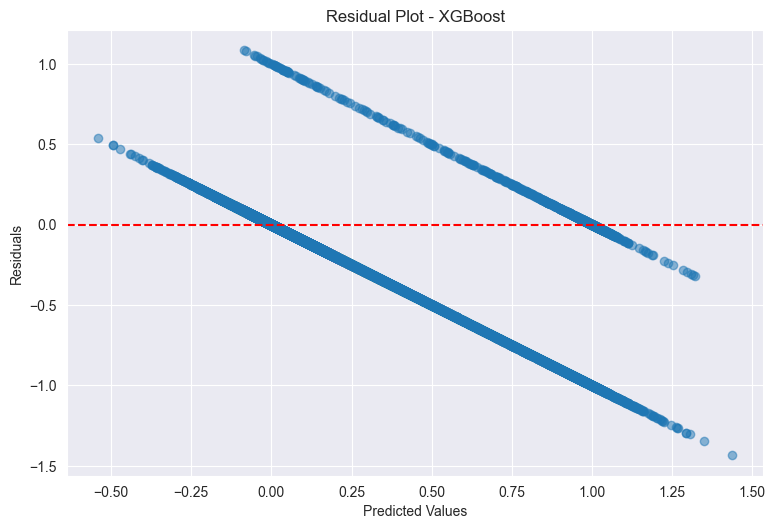


Best Model: XGBoost with RMSE 0.1407


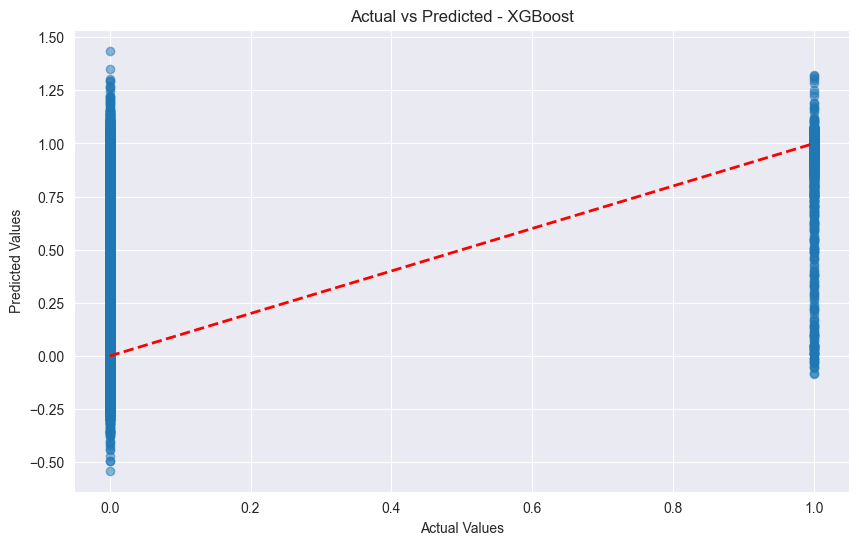


Risk Distribution in Predictions:
High Risk (>0.8): 1.33%
Medium Risk (0.5-0.8): 1.23%
Low Risk (<0.5): 97.43%

Top 10 Most Important Features:
                               Feature  Importance
59           mc_tx_succ_count_lifetime    0.455204
5          mc_billpay_br_count_last_1y    0.037591
53      mc_tx_amount_succ_sum_lifetime    0.034919
33           mc_chip_tx_succ_count_30d    0.025311
28        mc_billpay_br_count_lifetime    0.018894
55  mc_tx_amount_decl_int_sum_lifetime    0.018386
71      mc_tx_cp_sum_decl_ext_last_24h    0.014611
19            mc_pur_br_count_lifetime    0.013514
29     mc_atm_br_tx_out_count_last_15d    0.013139
70           mc_tx_amount_sum_last_14d    0.013126


In [31]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from joblib import parallel_backend
from imblearn.under_sampling import RandomUnderSampler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load and prepare data
df = df_treated.copy()
X = df.drop(['infraction', 'event_created_at', 'merchant_id'], axis=1)
y = df['infraction']

# Time-based split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

# Apply Random UnderSampling only to training data
rus = RandomUnderSampler(sampling_strategy=0.25)  # This will make minority class (1) 20% of the data
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

# 2. Define regression models with parameter grids
models = {
    'XGBoost': (
        XGBRegressor(),
        {'model__learning_rate': [0.01, 0.25],
         'model__max_depth': [5, 50],
         'model__n_estimators': [20, 500]}
    )
}

# 3. Train and validate models
results = {}
best_estimators = {}

for model_name, (estimator, param_grid) in models.items():
    try:
        print(f"\n=== Training {model_name} ===")

        # Create pipeline without scaling
        pipeline = Pipeline([
            ('model', estimator)
        ])

        # Grid search with R² optimization
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring='neg_root_mean_squared_error',
            cv=KFold(n_splits=5, shuffle=True, random_state=42),
            n_jobs=-1,
            verbose=1
        )

        # Use multiprocessing backend for better memory management
        with parallel_backend('multiprocessing'):
            # Train on resampled training data
            grid.fit(X_train_resampled, y_train_resampled)

        # Store best model
        best_estimators[model_name] = grid.best_estimator_

        # Validate on original test set (not resampled)
        y_pred = grid.best_estimator_.predict(X_test)

        # Create single-row DataFrame for model results
        model_results = pd.DataFrame({
            'Best_Params': [str(grid.best_params_)],
            'R2_Score': [r2_score(y_test, y_pred)],
            'MSE': [mean_squared_error(y_test, y_pred)],
            'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred))],
            'MAE': [mean_absolute_error(y_test, y_pred)],
            'High_Risk_Precision': [np.mean(y_test[y_pred > 0.8] > 0.8)]
        }, index=[model_name])

        # Store predictions and residuals separately
        results[model_name] = {
            'predictions': y_pred,
            'residuals': y_test - y_pred,
            'metrics': model_results
        }

        # Print class distribution after resampling
        print("\nClass distribution in training data after resampling:")
        print(pd.Series(y_train_resampled).value_counts(normalize=True))

    except Exception as e:
        print(f"Error with {model_name}: {str(e)}")
        results[model_name] = 'Failed'

# 4. Combine results and display
results_df = pd.concat([results[model]['metrics'] for model in results if isinstance(results[model], dict)])
results_df.to_csv('regression_model_selection_results.csv', float_format='%.4f')

print("\nFinal Model Comparison:")
print(results_df[['R2_Score', 'RMSE', 'MAE', 'High_Risk_Precision']])


# 5. Select best model based on RMSE
best_model_name = results_df.index[results_df['RMSE'].argmin()]
best_model = best_estimators[best_model_name]
print(f"\nBest Model: {best_model_name} with RMSE {results_df.loc[best_model_name, 'RMSE']:.4f}")

# 6. Additional analysis for the best model
best_predictions = best_model.predict(X_test)
# Calculate and display risk distribution
risk_distribution = pd.Series({
    'High Risk (>0.8)': np.mean(best_predictions > 0.8),
    'Medium Risk (0.5-0.8)': np.mean((best_predictions > 0.5) & (best_predictions <= 0.8)),
    'Low Risk (<0.5)': np.mean(best_predictions <= 0.5)
})

print("\nRisk Distribution in Predictions:")
for threshold, percentage in risk_distribution.items():
    print(f"{threshold}: {percentage:.2%}")

# Feature importance analysis
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.named_steps['model'].feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10))

# Save predictions and actual values for further analysis
prediction_results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': best_predictions
})
prediction_results.to_csv('prediction_results.csv')

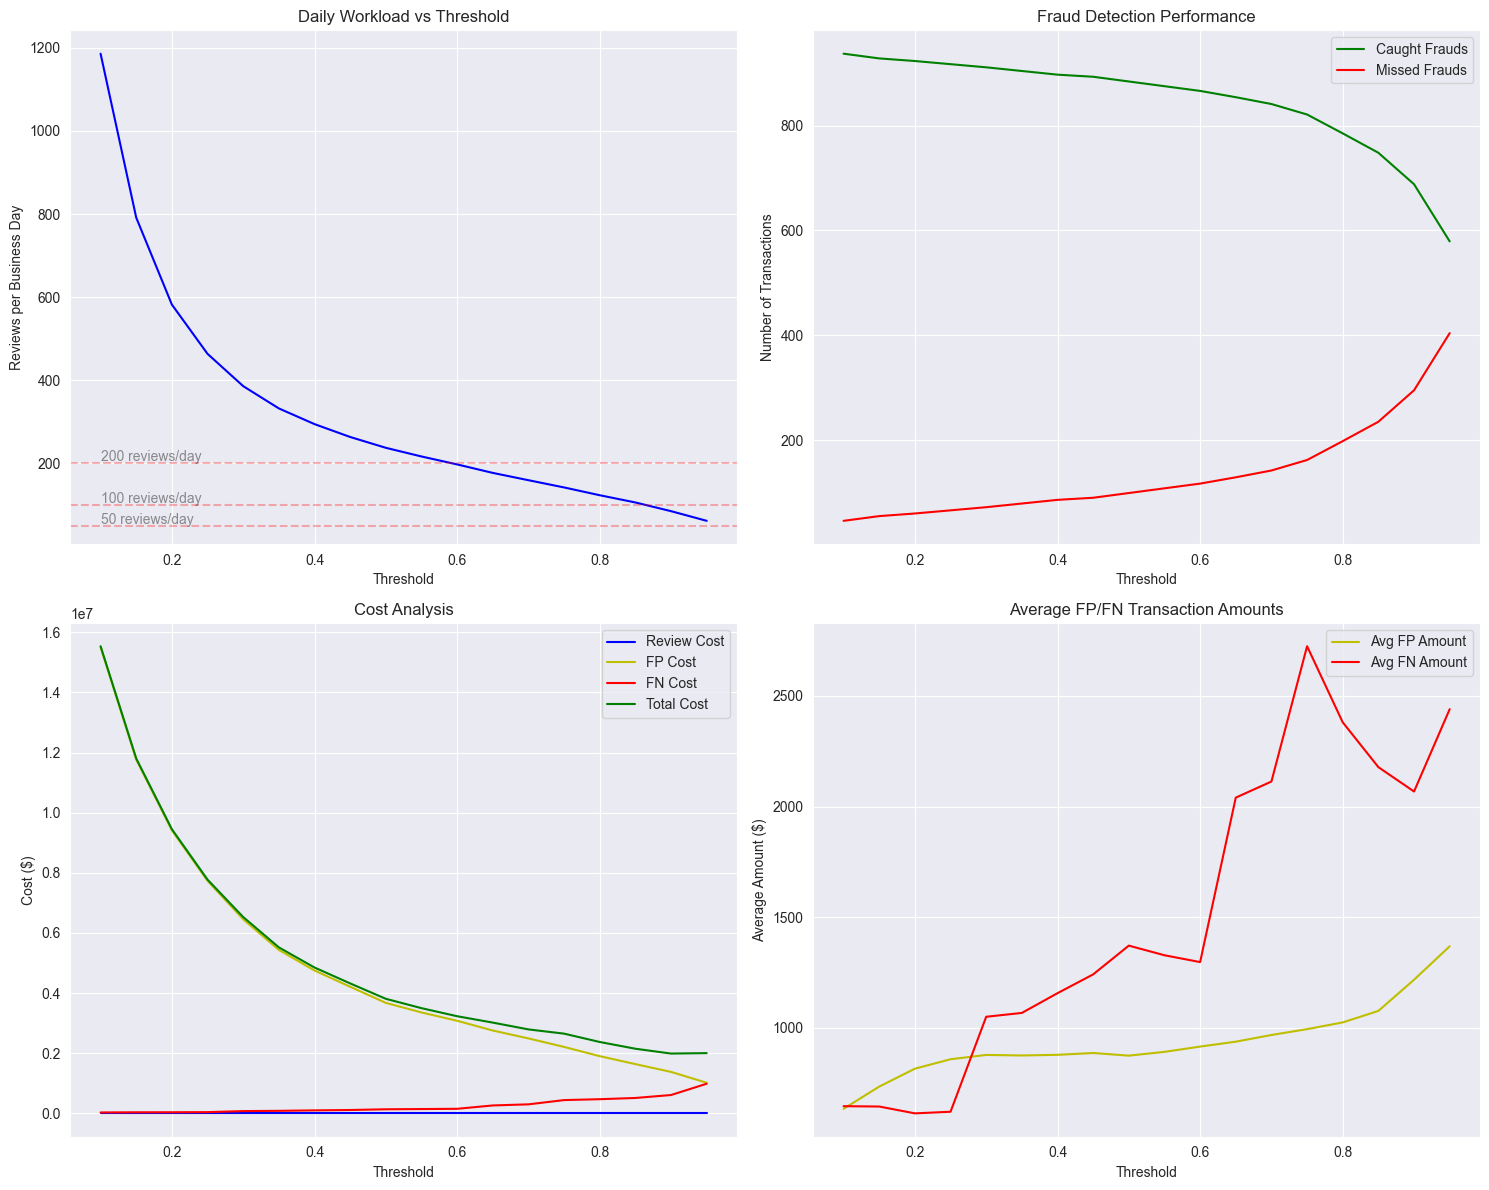


Optimal Threshold Analysis:
Optimal Threshold: 0.90
Percentage of Transactions to Review: 0.9%
Number of Transactions to Review: 1821
Reviews per Business Day: 85
Caught Frauds: 688
Missed Frauds: 295
False Positives: 1133

Cost Breakdown at Optimal Threshold:
Review Cost: $0.00
False Positive Cost: $1,378,736.47
False Negative Cost: $609,990.54
Total Cost: $1,988,727.01

Threshold Recommendations:

Threshold 0.3 - Conservative: High workload but catches most fraud
Reviews per Business Day: 464
Review Percentage: 5.0%
Caught Frauds: 917
Missed Frauds: 66
Total Cost: $7,772,829.39
Avg FN Amount: $620.16

Threshold 0.5 - Balanced: Moderate workload and fraud detection
Reviews per Business Day: 264
Review Percentage: 2.8%
Caught Frauds: 893
Missed Frauds: 90
Total Cost: $4,322,096.16
Avg FN Amount: $1,241.04

Threshold 0.7 - Aggressive: Lower workload but misses more fraud
Reviews per Business Day: 177
Review Percentage: 1.9%
Caught Frauds: 854
Missed Frauds: 129
Total Cost: $3,018,597.1

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

def analyze_verification_tradeoff(y_true, y_pred_proba, amount, cost_per_review=50,
                          test_period_days=30, business_days_per_week=5):
    """
    Analyze the tradeoff between human verification and missed fraud using actual transaction amounts

    Parameters:
    - y_true: True labels
    - y_pred_proba: Predicted probabilities from the model
    - amount: Array of transaction amounts corresponding to each prediction
    - cost_per_review: Cost of human review per transaction
    - test_period_days: Number of days covered by the test dataset
    - business_days_per_week: Number of working days per week
    """
    # Calculate business days in the period
    weeks_in_period = test_period_days / 7
    business_days_in_period = weeks_in_period * business_days_per_week

    results = []
    for threshold in np.arange(0.1, 1.0, 0.05):
        # Predictions at this threshold
        y_pred = (y_pred_proba >= threshold).astype(int)

        # Get indices for each case
        fp_indices = (y_pred == 1) & (y_true == 0)  # False Positives
        fn_indices = (y_pred == 0) & (y_true == 1)  # False Negatives

        # Calculate costs using actual transaction amounts
        fp_cost = amount[fp_indices].sum()  # Cost of unnecessary reviews
        fn_cost = amount[fn_indices].sum()  # Cost of missed frauds

        # Calculate number of transactions to review
        transactions_to_review = (y_pred_proba >= threshold).sum()
        review_cost = transactions_to_review * cost_per_review

        # Calculate total cost
        total_cost = fp_cost + fn_cost + review_cost

        # Calculate metrics
        total_transactions = len(y_true)
        review_percentage = (transactions_to_review / total_transactions) * 100

        # Get confusion matrix numbers
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        # Calculate daily review workload
        reviews_per_business_day = transactions_to_review / business_days_in_period

        results.append({
            'Threshold': threshold,
            'Transactions to Review': transactions_to_review,
            'Reviews per Business Day': reviews_per_business_day,
            'Review Percentage': review_percentage,
            'Missed Frauds': fn,
            'Caught Frauds': tp,
            'False Positives': fp,
            'Review Cost': review_cost,
            'FP Cost (Unnecessary Reviews)': fp_cost,
            'FN Cost (Missed Frauds)': fn_cost,
            'Total Cost': total_cost,
            'Avg FP Amount': fp_cost/fp if fp > 0 else 0,
            'Avg FN Amount': fn_cost/fn if fn > 0 else 0
        })

    results_df = pd.DataFrame(results)

    # Plotting
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # Plot 1: Daily Reviews vs Threshold
    ax1.plot(results_df['Threshold'], results_df['Reviews per Business Day'], 'b-')
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Reviews per Business Day')
    ax1.set_title('Daily Workload vs Threshold')
    ax1.grid(True)

    # Add horizontal lines for different staffing levels
    staffing_levels = [50, 100, 200]  # Example staffing levels
    for level in staffing_levels:
        ax1.axhline(y=level, color='r', linestyle='--', alpha=0.3)
        ax1.text(0.1, level + 5, f'{level} reviews/day', alpha=0.5)

    # Plot 2: Caught vs Missed Frauds
    ax2.plot(results_df['Threshold'], results_df['Caught Frauds'], 'g-', label='Caught Frauds')
    ax2.plot(results_df['Threshold'], results_df['Missed Frauds'], 'r-', label='Missed Frauds')
    ax2.set_xlabel('Threshold')
    ax2.set_ylabel('Number of Transactions')
    ax2.set_title('Fraud Detection Performance')
    ax2.legend()
    ax2.grid(True)

    # Plot 3: Costs Analysis
    ax3.plot(results_df['Threshold'], results_df['Review Cost'], 'b-', label='Review Cost')
    ax3.plot(results_df['Threshold'], results_df['FP Cost (Unnecessary Reviews)'], 'y-', label='FP Cost')
    ax3.plot(results_df['Threshold'], results_df['FN Cost (Missed Frauds)'], 'r-', label='FN Cost')
    ax3.plot(results_df['Threshold'], results_df['Total Cost'], 'g-', label='Total Cost')
    ax3.set_xlabel('Threshold')
    ax3.set_ylabel('Cost ($)')
    ax3.set_title('Cost Analysis')
    ax3.legend()
    ax3.grid(True)

    # Plot 4: Average Transaction Amounts for FP and FN
    ax4.plot(results_df['Threshold'], results_df['Avg FP Amount'], 'y-', label='Avg FP Amount')
    ax4.plot(results_df['Threshold'], results_df['Avg FN Amount'], 'r-', label='Avg FN Amount')
    ax4.set_xlabel('Threshold')
    ax4.set_ylabel('Average Amount ($)')
    ax4.set_title('Average FP/FN Transaction Amounts')
    ax4.legend()
    ax4.grid(True)

    plt.tight_layout()
    plt.show()

    # Find optimal threshold based on total cost
    optimal_idx = results_df['Total Cost'].idxmin()
    optimal_threshold = results_df.loc[optimal_idx, 'Threshold']
    optimal_review_pct = results_df.loc[optimal_idx, 'Review Percentage']

    print("\nOptimal Threshold Analysis:")
    print(f"Optimal Threshold: {optimal_threshold:.2f}")
    print(f"Percentage of Transactions to Review: {optimal_review_pct:.1f}%")
    print(f"Number of Transactions to Review: {results_df.loc[optimal_idx, 'Transactions to Review']:.0f}")
    print(f"Reviews per Business Day: {results_df.loc[optimal_idx, 'Reviews per Business Day']:.0f}")
    print(f"Caught Frauds: {results_df.loc[optimal_idx, 'Caught Frauds']:.0f}")
    print(f"Missed Frauds: {results_df.loc[optimal_idx, 'Missed Frauds']:.0f}")
    print(f"False Positives: {results_df.loc[optimal_idx, 'False Positives']:.0f}")
    print(f"\nCost Breakdown at Optimal Threshold:")
    print(f"Review Cost: ${results_df.loc[optimal_idx, 'Review Cost']:,.2f}")
    print(f"False Positive Cost: ${results_df.loc[optimal_idx, 'FP Cost (Unnecessary Reviews)']:,.2f}")
    print(f"False Negative Cost: ${results_df.loc[optimal_idx, 'FN Cost (Missed Frauds)']:,.2f}")
    print(f"Total Cost: ${results_df.loc[optimal_idx, 'Total Cost']:,.2f}")

    # Create threshold recommendations table
    recommendations = pd.DataFrame({
        'Threshold': [0.3, 0.5, 0.7, 0.9],
        'Description': [
            'Conservative: High workload but catches most fraud',
            'Balanced: Moderate workload and fraud detection',
            'Aggressive: Lower workload but misses more fraud',
            'Very Aggressive: Minimal workload but high risk'
        ]
    })

    print("\nThreshold Recommendations:")
    for _, row in recommendations.iterrows():
        thresh_data = results_df[results_df['Threshold'].round(1) == row['Threshold']].iloc[0]
        print(f"\nThreshold {row['Threshold']} - {row['Description']}")
        print(f"Reviews per Business Day: {thresh_data['Reviews per Business Day']:.0f}")
        print(f"Review Percentage: {thresh_data['Review Percentage']:.1f}%")
        print(f"Caught Frauds: {thresh_data['Caught Frauds']:.0f}")
        print(f"Missed Frauds: {thresh_data['Missed Frauds']:.0f}")
        print(f"Total Cost: ${thresh_data['Total Cost']:,.2f}")
        print(f"Avg FN Amount: ${thresh_data['Avg FN Amount']:,.2f}")

    return results_df, optimal_threshold

# Use the best model to get predictions
best_predictions_proba = best_model.predict(X_test)

# Assuming amount is a column in your original dataframe
# You'll need to adjust this based on your actual data structure
amount = X_test['amount']  # adjust column name as needed

# Run the analysis
results_df, optimal_threshold = analyze_verification_tradeoff(
    y_test,
    best_predictions_proba,
    amount,
    cost_per_review=0,  # Adjust based on your actual review cost
    test_period_days=30,  # Adjust based on your test dataset timespan
    business_days_per_week=5  # Adjust if working weekends
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

def calculate_amount_based_costs(y_true, y_pred_proba, threshold, transaction_amounts):
    """
    Calculate costs based on transaction amounts:
    - False Positive: Cost is the transaction amount (blocking legitimate transaction)
    - False Negative: Cost is the transaction amount (letting fraudulent transaction through)
    - True Positive and True Negative: No cost (0)
    """
    # Convert probabilities to binary predictions based on threshold
    y_pred = (y_pred_proba >= threshold).astype(int)

    # Get indices for each case
    true_pos_idx = (y_true == 1) & (y_pred == 1)
    true_neg_idx = (y_true == 0) & (y_pred == 0)
    false_pos_idx = (y_true == 0) & (y_pred == 1)
    false_neg_idx = (y_true == 1) & (y_pred == 0)

    # Calculate costs using transaction amounts
    fp_cost = transaction_amounts[false_pos_idx].sum()  # Cost of blocking legitimate transactions
    fn_cost = transaction_amounts[false_neg_idx].sum()  # Cost of missed fraud
    total_cost = fp_cost + fn_cost

    # Calculate confusion matrix elements
    tn = np.sum(true_neg_idx)
    fp = np.sum(false_pos_idx)
    fn = np.sum(false_neg_idx)
    tp = np.sum(true_pos_idx)

    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'threshold': threshold,
        'total_cost': total_cost,
        'fp_cost': fp_cost,
        'fn_cost': fn_cost,
        'cost_per_transaction': total_cost / len(y_true),
        'true_positives': tp,
        'false_positives': fp,
        'true_negatives': tn,
        'false_negatives': fn,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'average_fp_cost': fp_cost / fp if fp > 0 else 0,
        'average_fn_cost': fn_cost / fn if fn > 0 else 0
    }

# Get predictions from best model
y_pred_proba = best_model.predict(X_test)

# Assuming transaction_amount is a column in your dataset
# If it's not, you'll need to modify this part to get the actual transaction amounts
transaction_amounts = X_test['transaction_amount'] if 'transaction_amount' in X_test.columns else np.ones(len(y_test))

# Test range of thresholds
thresholds = np.linspace(0, 1, 100)
results = []

for threshold in thresholds:
    result = calculate_amount_based_costs(y_test, y_pred_proba, threshold, transaction_amounts)
    results.append(result)

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Create visualizations
plt.figure(figsize=(15, 10))

# Plot 1: Total Cost Components vs Threshold
plt.subplot(2, 2, 1)
plt.plot(results_df['threshold'], results_df['fp_cost'], label='False Positive Cost')
plt.plot(results_df['threshold'], results_df['fn_cost'], label='False Negative Cost')
plt.plot(results_df['threshold'], results_df['total_cost'], label='Total Cost')
plt.xlabel('Threshold')
plt.ylabel('Cost ($)')
plt.title('Cost Components vs Threshold')
plt.legend()
plt.grid(True)

# Plot 2: Precision, Recall, F1 vs Threshold
plt.subplot(2, 2, 2)
plt.plot(results_df['threshold'], results_df['precision'], label='Precision')
plt.plot(results_df['threshold'], results_df['recall'], label='Recall')
plt.plot(results_df['threshold'], results_df['f1_score'], label='F1 Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metrics vs Threshold')
plt.legend()
plt.grid(True)

# Plot 3: Average Cost per Error Type
plt.subplot(2, 2, 3)
plt.plot(results_df['threshold'], results_df['average_fp_cost'], label='Avg FP Cost')
plt.plot(results_df['threshold'], results_df['average_fn_cost'], label='Avg FN Cost')
plt.xlabel('Threshold')
plt.ylabel('Average Cost per Error ($)')
plt.title('Average Cost per Error Type')
plt.legend()
plt.grid(True)

# Plot 4: Error Counts
plt.subplot(2, 2, 4)
plt.plot(results_df['threshold'], results_df['false_positives'], label='False Positives')
plt.plot(results_df['threshold'], results_df['false_negatives'], label='False Negatives')
plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('Error Counts vs Threshold')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Find optimal thresholds for different metrics
optimal_thresholds = {
    'min_cost': results_df.loc[results_df['total_cost'].idxmin(), 'threshold'],
    'max_f1': results_df.loc[results_df['f1_score'].idxmax(), 'threshold'],
    'balanced': results_df.loc[
        (results_df['precision'] - results_df['recall']).abs().idxmin(),
        'threshold'
    ]
}

# Display optimal thresholds and their implications
print("\nOptimal Thresholds Analysis:")
print("-" * 50)
for metric, threshold in optimal_thresholds.items():
    result = results_df[results_df['threshold'] == threshold].iloc[0]
    print(f"\nOptimal threshold for {metric}: {threshold:.3f}")
    print(f"Total Cost: ${result['total_cost']:,.2f}")
    print(f"False Positive Cost: ${result['fp_cost']:,.2f}")
    print(f"False Negative Cost: ${result['fn_cost']:,.2f}")
    print(f"Average FP Cost: ${result['average_fp_cost']:,.2f}")
    print(f"Average FN Cost: ${result['average_fn_cost']:,.2f}")
    print(f"Precision: {result['precision']:.3f}")
    print(f"Recall: {result['recall']:.3f}")
    print(f"F1 Score: {result['f1_score']:.3f}")

# Create confusion matrix heatmap for the minimum cost threshold
min_cost_threshold = optimal_thresholds['min_cost']
y_pred_min_cost = (y_pred_proba >= min_cost_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_min_cost)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix at Minimum Cost Threshold ({min_cost_threshold:.3f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Additional analysis: Distribution of transaction amounts in each prediction category
def analyze_amount_distribution(y_true, y_pred, amounts):
    categories = {
        'True Negative': (y_true == 0) & (y_pred == 0),
        'False Positive': (y_true == 0) & (y_pred == 1),
        'False Negative': (y_true == 1) & (y_pred == 0),
        'True Positive': (y_true == 1) & (y_pred == 1)
    }

    plt.figure(figsize=(12, 6))
    for name, mask in categories.items():
        if np.any(mask):
            plt.hist(amounts[mask], bins=30, alpha=0.5, label=name)

    plt.xlabel('Transaction Amount ($)')
    plt.ylabel('Count')
    plt.title('Distribution of Transaction Amounts by Prediction Category')
    plt.legend()
    plt.show()

# Analyze amount distribution for minimum cost threshold
y_pred_min_cost = (y_pred_proba >= min_cost_threshold).astype(int)
analyze_amount_distribution(y_test, y_pred_min_cost, transaction_amounts)

# Save results
results_df.to_csv('threshold_amount_analysis_results.csv', index=False)

# Unsupervised model candidates

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import EllipticEnvelope
from sklearn.metrics import precision_score, f1_score
from pyod.models.hbos import HBOS
from pyod.models.copod import COPOD
from pyod.models.ecod import ECOD
from sklearn.ensemble import IsolationForest
import optuna


class UnsupervisedAnomalyDetector:
    def __init__(self, contamination=0.05):
        self.contamination = contamination
        self.models = {}
        self.best_params = {}
        self.scores = {}

    def optimize_isolation_forest(self, X, trial):
        """Optimize IsolationForest hyperparameters"""
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'max_samples': trial.suggest_float('max_samples', 0.1, 1.0),
            'max_features': trial.suggest_float('max_features', 0.1, 1.0),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'contamination': self.contamination,
            'random_state': 42
        }

        model = IsolationForest(**params)
        model.fit(X)
        scores = -model.score_samples(X)
        return self._calculate_objective(scores)

    def optimize_lof(self, X, trial):
        """Optimize LocalOutlierFactor hyperparameters"""
        params = {
            'n_neighbors': trial.suggest_int('n_neighbors', 5, 50),
            'leaf_size': trial.suggest_int('leaf_size', 10, 100),
            'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan']),
            'contamination': self.contamination
        }

        model = LocalOutlierFactor(**params)
        scores = -model.fit_predict(X)
        return self._calculate_objective(scores)

    def optimize_hbos(self, X, trial):
        """Optimize HBOS hyperparameters"""
        params = {
            'n_bins': trial.suggest_int('n_bins', 5, 50),
            'alpha': trial.suggest_float('alpha', 0.1, 1.0),
            'tol': trial.suggest_float('tol', 0.1, 0.5),
            'contamination': self.contamination
        }

        model = HBOS(**params)
        model.fit(X)
        scores = model.decision_function(X)
        return self._calculate_objective(scores)

    def _calculate_objective(self, scores):
        """Calculate objective value for optimization"""
        threshold = np.percentile(scores, (1 - self.contamination) * 100)
        predictions = (scores > threshold).astype(int)
        return np.mean(predictions == (scores > np.median(scores)))

    def optimize_models(self, X, n_trials=100):
        """Optimize all models using Optuna"""
        optimization_funcs = {
            'IsolationForest': self.optimize_isolation_forest,
            'LOF': self.optimize_lof,
            'HBOS': self.optimize_hbos
        }

        for name, optimize_func in optimization_funcs.items():
            print(f"\nOptimizing {name}...")
            study = optuna.create_study(direction='maximize')
            study.optimize(lambda trial: optimize_func(X, trial), n_trials=n_trials)
            self.best_params[name] = study.best_params
            print(f"Best parameters for {name}: {study.best_params}")

    def fit_predict(self, X, y=None):
        """Fit and predict with all models"""
        # Initialize models with best parameters
        self.models['IsolationForest'] = IsolationForest(
            **self.best_params['IsolationForest'],
            contamination=self.contamination
        )

        self.models['LOF'] = LocalOutlierFactor(
            **self.best_params['LOF'],
            contamination=self.contamination
        )

        self.models['HBOS'] = HBOS(
            **self.best_params['HBOS'],
            contamination=self.contamination
        )

        # Add other state-of-the-art models with default parameters
        self.models['COPOD'] = COPOD(contamination=self.contamination)
        self.models['ECOD'] = ECOD(contamination=self.contamination)
        self.models['EllipticEnvelope'] = EllipticEnvelope(
            contamination=self.contamination,
            random_state=42
        )

        # Fit and predict with each model
        predictions = {}
        scores = {}

        for name, model in self.models.items():
            print(f"\nFitting {name}...")
            if isinstance(model, LocalOutlierFactor):
                predictions[name] = model.fit_predict(X)
                scores[name] = model.negative_outlier_factor_
            else:
                model.fit(X)
                predictions[name] = model.predict(X)
                scores[name] = model.decision_function(X) if hasattr(model, 'decision_function') \
                    else model.score_samples(X)

        return predictions, scores

    def evaluate(self, predictions, y_true):
        """Evaluate model performance if true labels are available"""
        results = {}

        for name, y_pred in predictions.items():
            # Convert predictions to binary (1 for anomaly, 0 for normal)
            y_pred_binary = (y_pred == -1).astype(int)

            results[name] = {
                'precision': precision_score(y_true, y_pred_binary),
                'recall': recall_score(y_true, y_pred_binary),
                'f1': f1_score(y_true, y_pred_binary)
            }

        return pd.DataFrame(results).T


def main():
    # Load data
    print("Loading data...")
    # df = pd.read_csv('raw_transactions.csv')
    df = df_treated.copy()

    # Prepare features
    X = df.drop(['infraction', 'event_created_at', 'merchant_id'], axis=1)
    y = df['infraction']  # Only used for evaluation

    # Initialize detector
    detector = UnsupervisedAnomalyDetector(contamination=0.05)  # 5% anomalies

    # Optimize models
    detector.optimize_models(X)

    # Fit and predict
    predictions, scores = detector.fit_predict(X)

    # Evaluate results
    results = detector.evaluate(predictions, y)
    print("\nModel Performance:")
    print(results)

    # Save results
    results.to_csv('unsupervised_model_results.csv')

    # Create DataFrame with all scores and predictions
    results_df = pd.DataFrame(index=df.index)

    for name in detector.models.keys():
        results_df[f'{name}_score'] = scores[name]
        results_df[f'{name}_prediction'] = predictions[name]

    # Add ensemble score (average of all normalized scores)
    normalized_scores = pd.DataFrame(scores).apply(lambda x: (x - x.mean()) / x.std())
    results_df['ensemble_score'] = normalized_scores.mean(axis=1)

    # Add original data and true labels
    results_df = pd.concat([df, results_df], axis=1)

    # Save detailed results
    results_df.to_csv('unsupervised_detailed_results.csv')

    return detector, results, results_df


if __name__ == "__main__":
    detector, results, results_df = main()

Loading data...


[I 2025-02-12 14:59:40,406] A new study created in memory with name: no-name-1f4c5f71-b7b3-450d-96a2-7667e801c3a3



Optimizing IsolationForest...


[I 2025-02-12 15:00:16,612] Trial 0 finished with value: 0.5500012601251052 and parameters: {'n_estimators': 146, 'max_samples': 0.27379766624480584, 'max_features': 0.10005217783088406, 'bootstrap': True}. Best is trial 0 with value: 0.5500012601251052.
[I 2025-02-12 15:01:13,572] Trial 1 finished with value: 0.5500012601251052 and parameters: {'n_estimators': 207, 'max_samples': 0.11104780973117924, 'max_features': 0.4230177401232913, 'bootstrap': True}. Best is trial 0 with value: 0.5500012601251052.
[I 2025-02-12 15:01:56,134] Trial 2 finished with value: 0.5500012601251052 and parameters: {'n_estimators': 87, 'max_samples': 0.7582915345351396, 'max_features': 0.59146532098031, 'bootstrap': False}. Best is trial 0 with value: 0.5500012601251052.
[I 2025-02-12 15:02:46,748] Trial 3 finished with value: 0.5500012601251052 and parameters: {'n_estimators': 153, 'max_samples': 0.9182328241557108, 'max_features': 0.22331511552283323, 'bootstrap': True}. Best is trial 0 with value: 0.5500

Best parameters for IsolationForest: {'n_estimators': 149, 'max_samples': 0.6314716080873201, 'max_features': 0.45015174184417606, 'bootstrap': True}

Optimizing LOF...


NameError: name 'LocalOutlierFactor' is not defined

In [ ]:
import numpy as np
import pandas as pd

# For model selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import recall_score, classification_report

# Unsupervised anomaly detection models
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# =============================================================================
# Define a custom scoring function for unsupervised models.
# Since these models output -1 for anomalies and 1 for inliers,
# we convert predictions so that:
#    -1 becomes 1 (suspicious) and 1 becomes 0 (normal),
# and then compute recall (i.e. fraction of true frauds that are flagged).
# =============================================================================
from sklearn.metrics import make_scorer


def unsupervised_recall_scorer(estimator, X, y):
    # For LOF and One-Class SVM, ensure that the model has been fitted with novelty=True if needed.
    y_pred = estimator.predict(X)
    # Convert: anomalies (-1) -> 1, inliers (1) -> 0
    y_pred_bin = np.where(y_pred == -1, 1, 0)
    return recall_score(y, y_pred_bin, zero_division=0)


unsupervised_recall = make_scorer(unsupervised_recall_scorer)

# =============================================================================
# Load data (raw, without scaling)
# =============================================================================
print("Loading data...")
# df = pd.read_csv('raw_transactions.csv')
df = df_treated.copy()

# Prepare features by dropping columns not used for prediction.
X = df.drop(['infraction', 'event_created_at', 'merchant_id'], axis=1)
y = df['infraction']

print(f"Data shape: {X.shape}")
print(f"Number of fraud cases: {sum(y == 1)}")
print(f"Fraud ratio: {sum(y == 1) / len(y):.4%}")

# Train-test split (stratify so that test set maintains the original distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# =============================================================================
# Define unsupervised candidate models with parameter grids.
# Note: For LOF, we must set novelty=True so that it can be used on new (test) data.
# =============================================================================
unsupervised_models = {
    "Isolation Forest": {
        "estimator": IsolationForest(random_state=42),
        "param_grid": {
            "n_estimators": [100, 200],
            "max_samples": [0.5, 0.75, 1.0],
            "contamination": [0.0005, 0.001, 0.005]
        }
    },
    "Local Outlier Factor": {
        # Set novelty=True to enable predicting on unseen data.
        "estimator": LocalOutlierFactor(novelty=True),
        "param_grid": {
            "n_neighbors": [20, 30, 50],
            "contamination": [0.0005, 0.001, 0.005]
        }
    },
    "One-Class SVM": {
        "estimator": OneClassSVM(kernel='rbf'),
        "param_grid": {
            "nu": [0.0005, 0.001, 0.005],  # nu is an upper bound on the fraction of training errors
            "gamma": ['scale', 0.001, 0.01, 0.1]
        }
    }
}

# =============================================================================
# Hyperparameter tuning for each unsupervised model using GridSearchCV.
# We use our custom unsupervised_recall scorer.
# =============================================================================
best_unsupervised_models = {}

print("\n--- Hyperparameter Tuning for Unsupervised Models ---")
for model_name, model_info in unsupervised_models.items():
    print(f"\n----- {model_name} -----")
    grid = GridSearchCV(
        estimator=model_info["estimator"],
        param_grid=model_info["param_grid"],
        scoring=unsupervised_recall,
        cv=5,  # 5-fold cross-validation on the training set
        n_jobs=-1,
        verbose=1
    )
    # Fit grid search on the training set (which remains unaltered)
    grid.fit(X_train, y_train)
    print(f"Best parameters for {model_name}: {grid.best_params_}")
    print(f"Best CV Recall for {model_name}: {grid.best_score_:.4f}")
    best_unsupervised_models[model_name] = grid.best_estimator_

# =============================================================================
# Evaluate each candidate unsupervised model on the test set.
# =============================================================================
print("\n--- Evaluation on Test Set for Unsupervised Models ---")
unsupervised_results = {}

for model_name, model in best_unsupervised_models.items():
    print(f"\nEvaluating {model_name}...")
    # Use predict on test set; convert -1 to 1 (suspicious) and 1 to 0 (normal)
    y_pred = model.predict(X_test)
    y_pred_bin = np.where(y_pred == -1, 1, 0)

    recall_val = recall_score(y_test, y_pred_bin, zero_division=0)
    print(classification_report(y_test, y_pred_bin, zero_division=0))

    unsupervised_results[model_name] = recall_val
    print(f"Test Recall for {model_name}: {recall_val:.4f}")

# Select the best unsupervised model (based on recall on test set)
best_unsupervised_model_name = max(unsupervised_results, key=unsupervised_results.get)
print(
    f"\nSelected Unsupervised Model: {best_unsupervised_model_name} with Test Recall = {unsupervised_results[best_unsupervised_model_name]:.4f}")

# =============================================================================
# With the winning unsupervised model, generate anomaly scores and rank transactions.
# =============================================================================
winning_model = best_unsupervised_models[best_unsupervised_model_name]

# For models that support decision_function (e.g., Isolation Forest, One-Class SVM, LOF with novelty=True)
# lower scores (more negative) indicate higher anomaly.
if hasattr(winning_model, "decision_function"):
    anomaly_scores = winning_model.decision_function(X)
else:
    # If decision_function is not available, we can use negative of predict_proba if available,
    # or simply use the raw predictions.
    anomaly_scores = -winning_model.predict(X)

# Append anomaly scores to the original dataframe (use the full dataset for ranking)
df['anomaly_score'] = anomaly_scores

# Rank transactions: most suspicious first (i.e. smallest decision function score)
df_ranked = df.sort_values('anomaly_score', ascending=True)

# For instance, select the top 100 most suspicious transactions:
top_100_anomalies = df_ranked.head(100)
print("\nTop 100 most suspicious transactions:")
print(top_100_anomalies[['anomaly_score', 'infraction']])

# The ranked list can now be used by your fraud team to prioritize cases for human evaluation.
